<a href="https://colab.research.google.com/github/Cachenn/CV-MISIS/blob/develop/diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import copy

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

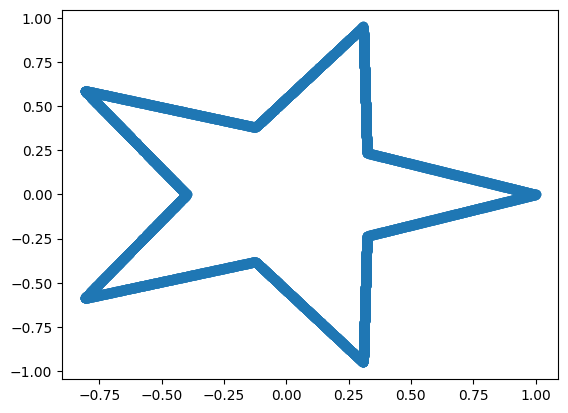

In [ ]:
def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=1000, center=(0, 0)):
    points = []
    angle_step = np.pi / n_spikes

    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius

        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])
    vertices.append(vertices[0])

    vertices = np.array(vertices)
    sampled_points = []

    for i in range(len(vertices) - 1):
        start_point = vertices[i]
        end_point = vertices[i + 1]

        for t in np.linspace(0, 1, n_samples // (len(vertices) - 1)):
            point = (1 - t) * start_point + t * end_point
            sampled_points.append(point)

    return np.array(sampled_points)


s = generate_star(n_samples=5000)

plt.scatter(s[:, 0], s[:, 1])
plt.show()

In [ ]:
class Config:
    lr = 1e-3
    epochs = 1200
    batch_size = 512
    hidden_dim = 256
    num_timesteps = 1000
    data_samples = 5000

    # VP-SDE params
    beta_min = 0.1
    beta_max = 20.0
    eps = 1e-5

    # cosine schedule params
    cosine_s = 0.008

    # experiment params
    schedule = 'linear'      # 'linear' или 'cosine'
    loss_weighting = 'none'

    # training target
    predict = 'eps'          # для этой версии делаем eps-prediction

    # sampling
    sample_clip = 3.0

In [ ]:
class ScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.config = config

        self.time_embed = nn.Sequential(
            nn.Linear(1, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.ReLU()
        )

        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, 2)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)
        return self.net(x_input)

In [ ]:
def beta_t(t, config):
    """
    beta(t) for VP-SDE
    """
    if config.schedule == 'linear':
        return config.beta_min + t * (config.beta_max - config.beta_min)

    elif config.schedule == 'cosine':
        # cosine alpha_bar(t), then beta(t) = - d/dt log(alpha_bar(t))
        s = config.cosine_s
        u = (t + s) / (1.0 + s)
        u = torch.clamp(u, config.eps, 1.0 - config.eps)

        # alpha_bar(t) = cos^2(pi/2 * u) / cos^2(pi/2 * s/(1+s))
        # log alpha_bar = 2 log cos(pi/2 * u) - const
        # d/dt log alpha_bar = - pi/(1+s) * tan(pi/2 * u)
        # beta(t) = - d/dt log alpha_bar = pi/(1+s) * tan(pi/2 * u)
        beta = (math.pi / (1.0 + s)) * torch.tan((math.pi / 2.0) * u)

        return torch.clamp(beta, min=config.beta_min, max=100.0)

    else:
        raise ValueError(f'Unknown schedule: {config.schedule}')


def integral_beta(t, config):
    if config.schedule == 'linear':
        return config.beta_min * t + 0.5 * (config.beta_max - config.beta_min) * t ** 2

    elif config.schedule == 'cosine':
        s = config.cosine_s
        c0 = math.cos((math.pi / 2.0) * (s / (1.0 + s))) ** 2

        u = (t + s) / (1.0 + s)
        u = torch.clamp(u, 0.0, 1.0 - config.eps)

        alpha_bar = (torch.cos((math.pi / 2.0) * u) ** 2) / c0
        alpha_bar = torch.clamp(alpha_bar, min=1e-12)

        return -torch.log(alpha_bar)

    else:
        raise ValueError(f'Unknown schedule: {config.schedule}')


def alpha_bar_t(t, config):
    return torch.exp(-integral_beta(t, config))


def mean_coeff_t(t, config):
    return torch.exp(-0.5 * integral_beta(t, config))


def std_t(t, config):
    ab = alpha_bar_t(t, config)
    return torch.sqrt(torch.clamp(1.0 - ab, min=1e-12))


def g_t(t, config):
    return torch.sqrt(beta_t(t, config))


def snr_t(t, config):
    ab = alpha_bar_t(t, config)
    return ab / torch.clamp(1.0 - ab, min=1e-12)


def sample_q_t(x0, t, config):
    eps = torch.randn_like(x0)
    mean_coeff = mean_coeff_t(t, config)
    std = std_t(t, config)
    x_t = mean_coeff * x0 + std * eps
    return x_t, eps

In [ ]:
class VPTrainer:
    def __init__(self, config):
        self.config = copy.deepcopy(config)
        self.device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(
            self.dataset,
            batch_size=config.batch_size,
            shuffle=True,
            drop_last=False
        )

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

        self.loss_history = []

    def get_loss_weight(self, t):
        if self.config.loss_weighting == 'none':
            return torch.ones_like(t)

        elif self.config.loss_weighting == 'snr':
            return snr_t(t, self.config)

        elif self.config.loss_weighting == 'inv_snr':
            return 1.0 / torch.clamp(snr_t(t, self.config), min=1e-6)

        elif self.config.loss_weighting == 'beta':
            return beta_t(t, self.config)

        else:
            raise ValueError(f'Unknown loss weighting: {self.config.loss_weighting}')

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch,) in self.dataloader:
            batch = batch.to(self.device)

            t = torch.rand(batch.shape[0], 1, device=self.device)
            t = torch.clamp(t, self.config.eps, 1.0 - self.config.eps)

            x_t, eps = sample_q_t(batch, t, self.config)

            pred_eps = self.model(x_t, t)

            per_sample = ((pred_eps - eps) ** 2).sum(dim=1, keepdim=True)
            w = self.get_loss_weight(t)
            loss = (w * per_sample).mean()

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item() * batch.shape[0]

        avg_loss = total_loss / len(self.data)
        self.loss_history.append(avg_loss)
        return avg_loss

    def run(self, verbose_every=100):
        for epoch in range(self.config.epochs):
            loss = self.train_epoch()
            if epoch % verbose_every == 0:
                print(
                    f"[{self.config.schedule} | {self.config.loss_weighting}] "
                    f"epoch={epoch}, loss={loss:.6f}"
                )

In [ ]:
config = Config()
trainer = VPTrainer(config)

In [ ]:
trainer.run()

[linear | none] epoch=0, loss=1.623347
[linear | none] epoch=100, loss=0.338057
[linear | none] epoch=200, loss=0.313317
[linear | none] epoch=300, loss=0.320269
[linear | none] epoch=400, loss=0.305458
[linear | none] epoch=500, loss=0.310730
[linear | none] epoch=600, loss=0.314524
[linear | none] epoch=700, loss=0.321806
[linear | none] epoch=800, loss=0.293451
[linear | none] epoch=900, loss=0.298730
[linear | none] epoch=1000, loss=0.302282
[linear | none] epoch=1100, loss=0.311728


In [ ]:
def sample_vp_sde(model, config, num_samples=1000):
    device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
    model.eval()

    with torch.no_grad():
        # For VP-SDE prior is N(0, I)
        x = torch.randn(num_samples, 2, device=device)

        dt = 1.0 / config.num_timesteps

        for i in range(config.num_timesteps):
            t = 1.0 - i * dt
            t = max(t, config.eps)
            t_tensor = torch.full((num_samples, 1), t, device=device)

            beta = beta_t(t_tensor, config)
            g = g_t(t_tensor, config)
            std = std_t(t_tensor, config)

            pred_eps = model(x, t_tensor)
            score = -pred_eps / torch.clamp(std, min=1e-6)

            # reverse-time SDE:
            # dx = [f(x,t) - g(t)^2 score] dt + g(t) d\bar{w}
            # when stepping backward with Euler-Maruyama:
            # x_{t-dt} = x_t - [f - g^2 score] dt + g sqrt(dt) z
            f = -0.5 * beta * x
            drift = -(f - (g ** 2) * score) * dt
            diffusion = g * torch.randn_like(x) * math.sqrt(dt)

            x = x + drift + diffusion
            x = torch.clamp(x, -config.sample_clip, config.sample_clip)

        return x.cpu().numpy()

In [ ]:
samples = sample_vp_sde(trainer.model, trainer.config, 1000)

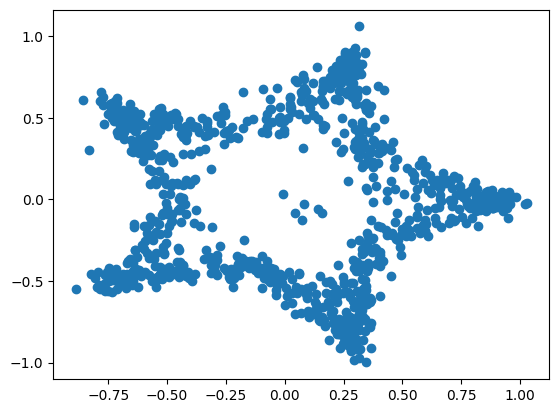

In [ ]:
plt.scatter(samples[:, 0], samples[:, 1])
plt.show()

In [ ]:
def run_experiment(schedule, loss_weighting, epochs=None):
    cfg = Config()
    cfg.schedule = schedule
    cfg.loss_weighting = loss_weighting
    if epochs is not None:
        cfg.epochs = epochs

    trainer = VPTrainer(cfg)
    trainer.run(verbose_every=200)
    samples = sample_vp_sde(trainer.model, trainer.config, 1000)

    return {
        'config': cfg,
        'trainer': trainer,
        'samples': samples,
        'final_loss': trainer.loss_history[-1]
    }

In [ ]:
 experiments_to_run = [
    ('linear', 'none'),
    ('linear', 'snr'),
    ('linear', 'inv_snr'),
    ('linear', 'beta'),
    ('cosine', 'none'),
    ('cosine', 'snr'),
    ('cosine', 'inv_snr'),
    ('cosine', 'beta'),
]

In [ ]:
results = {}

for schedule, weighting in experiments_to_run:
    print('=' * 80)
    print(f'Running: schedule={schedule}, weighting={weighting}')
    res = run_experiment(schedule, weighting, epochs=1200)
    results[(schedule, weighting)] = res

Running: schedule=linear, weighting=none
[linear | none] epoch=0, loss=1.689646
[linear | none] epoch=200, loss=0.317347
[linear | none] epoch=400, loss=0.317762
[linear | none] epoch=600, loss=0.320827
[linear | none] epoch=800, loss=0.309799
[linear | none] epoch=1000, loss=0.304538
Running: schedule=linear, weighting=snr
[linear | snr] epoch=0, loss=160.489580
[linear | snr] epoch=200, loss=89.523367
[linear | snr] epoch=400, loss=131.985007
[linear | snr] epoch=600, loss=60.771399
[linear | snr] epoch=800, loss=165.551948
[linear | snr] epoch=1000, loss=68.961605
Running: schedule=linear, weighting=inv_snr
[linear | inv_snr] epoch=0, loss=2036.362573
[linear | inv_snr] epoch=200, loss=1.455511
[linear | inv_snr] epoch=400, loss=0.564339
[linear | inv_snr] epoch=600, loss=0.485840
[linear | inv_snr] epoch=800, loss=0.484076
[linear | inv_snr] epoch=1000, loss=0.473603
Running: schedule=linear, weighting=beta
[linear | beta] epoch=0, loss=15.970653
[linear | beta] epoch=200, loss=0.9

In [ ]:
rows = []
for (schedule, weighting), res in results.items():
    rows.append({
        'schedule': schedule,
        'loss_weighting': weighting,
        'final_loss': res['final_loss']
    })

df_results = pd.DataFrame(rows).sort_values(['schedule', 'final_loss'])
df_results

,schedule,loss_weighting,final_loss
4,cosine,none,0.545730
7,cosine,beta,0.880867
6,cosine,inv_snr,13.341700
5,cosine,snr,225.767963
0,linear,none,0.300699
2,linear,inv_snr,0.501322
3,linear,beta,0.843771
1,linear,snr,71.824905


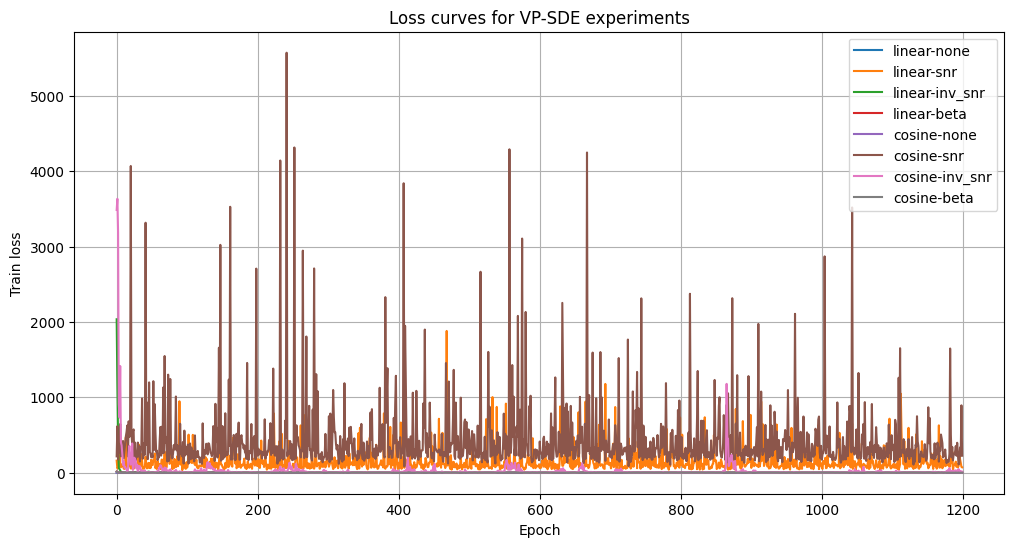

In [ ]:
plt.figure(figsize=(12, 6))

for (schedule, weighting), res in results.items():
    label = f'{schedule}-{weighting}'
    plt.plot(res['trainer'].loss_history, label=label)

plt.xlabel('Epoch')
plt.ylabel('Train loss')
plt.title('Loss curves for VP-SDE experiments')
plt.legend()
plt.grid(True)
plt.show()

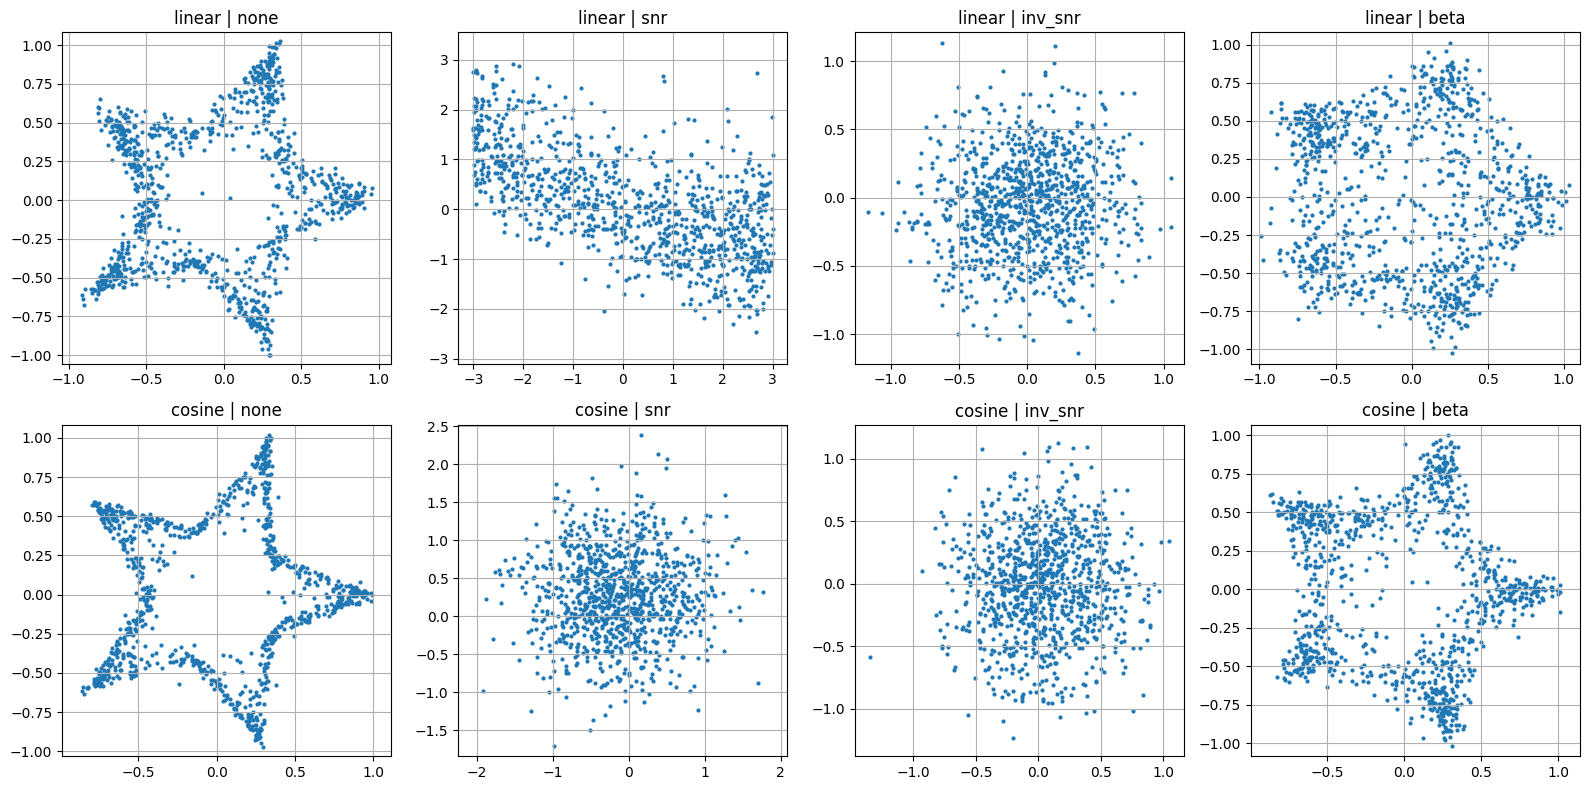

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, ((schedule, weighting), res) in zip(axes.flatten(), results.items()):
    samples = res['samples']
    ax.scatter(samples[:, 0], samples[:, 1], s=4)
    ax.set_title(f'{schedule} | {weighting}')
    ax.axis('equal')
    ax.grid(True)

plt.tight_layout()
plt.show()

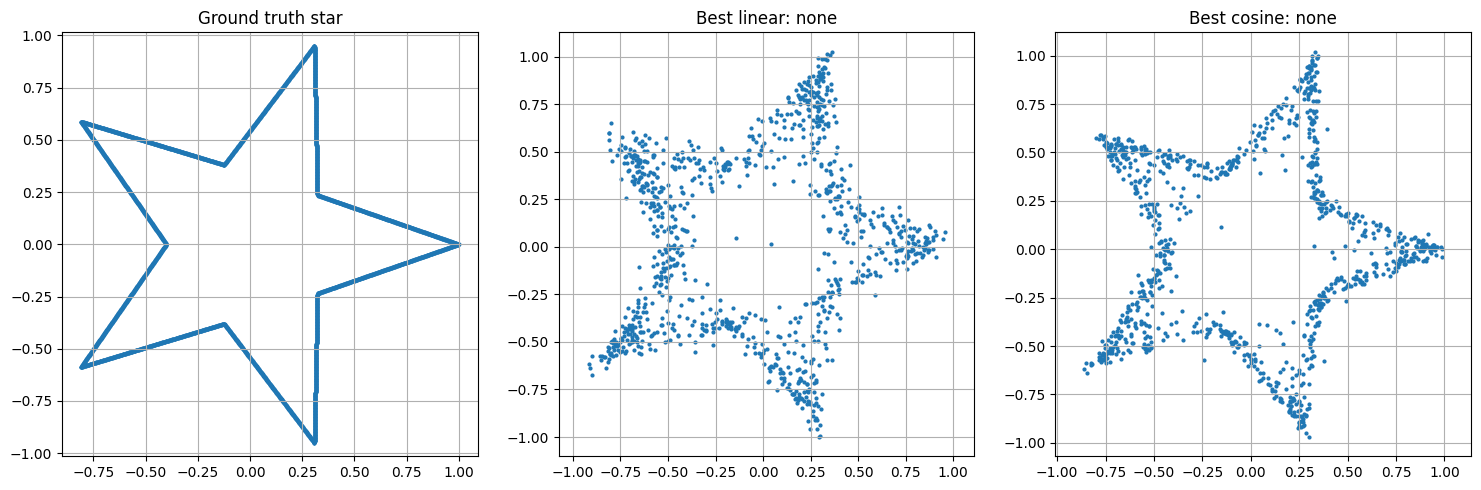

In [ ]:
best_linear = None
best_cosine = None

linear_candidates = [(k, v) for k, v in results.items() if k[0] == 'linear']
cosine_candidates = [(k, v) for k, v in results.items() if k[0] == 'cosine']

best_linear = min(linear_candidates, key=lambda x: x[1]['final_loss'])
best_cosine = min(cosine_candidates, key=lambda x: x[1]['final_loss'])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(s[:, 0], s[:, 1], s=3)
axes[0].set_title('Ground truth star')
axes[0].axis('equal')
axes[0].grid(True)

axes[1].scatter(best_linear[1]['samples'][:, 0], best_linear[1]['samples'][:, 1], s=4)
axes[1].set_title(f'Best linear: {best_linear[0][1]}')
axes[1].axis('equal')
axes[1].grid(True)

axes[2].scatter(best_cosine[1]['samples'][:, 0], best_cosine[1]['samples'][:, 1], s=4)
axes[2].set_title(f'Best cosine: {best_cosine[0][1]}')
axes[2].axis('equal')
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
print("Sorted results:")
display(df_results)

print("\nBest linear schedule:")
print(best_linear[0], best_linear[1]['final_loss'])

print("\nBest cosine schedule:")
print(best_cosine[0], best_cosine[1]['final_loss'])

Sorted results:


,schedule,loss_weighting,final_loss
4,cosine,none,0.545730
7,cosine,beta,0.880867
6,cosine,inv_snr,13.341700
5,cosine,snr,225.767963
0,linear,none,0.300699
2,linear,inv_snr,0.501322
3,linear,beta,0.843771
1,linear,snr,71.824905



Best linear schedule:
('linear', 'none') 0.30069916706085204

Best cosine schedule:
('cosine', 'none') 0.5457304210662842


Вывод: VP-SDE диффузия на задаче генерации звезды работает корректно, модель после обучения способна восстанавливать форму данных из шума и это показывает, что forward process, обучение и sampling реализованы также корректно
Перевзвешивание лосса по времени влияет неплохо на результат
Одни варианты дают более четкую форму звезды, другие делают генерацию более размытой, поэтому выбор весов важен для качества модели
Сравнение линейного и косинусного расписаний показало, что оба варианта работают, но качество генерации отличается
Удачным считается то расписание, при котором обучение идет стабильнее, а форма звезды получается более четкой
Для VP-SDE важны не только формулы модели, но и настройки как расписание шума и способ перевзвешивания лосса сильно влияют на итоговое качество генерации